In [1]:
import numpy as np
from Corrfunc.theory import wp
from Corrfunc.theory.DDrppi import DDrppi
import matplotlib.pyplot as plt
import matplotlib.colors as mplcolor
import statistics
import seaborn as sns
plt.style.use('MNRAS')

In [2]:
def error_data(rpavg_, wp_):
    wp_mean = []
    rpavg_mean = []
    stdev_ = []
    for i in range(len(wp_[0])):
        all_wp = []
        all_rpavg = []
        for arr in range(len(wp_)):
            all_wp.append(wp_[arr][i])
            all_rpavg.append(rpavg_[arr][i])
        wp_mean.append(statistics.mean(all_wp))
        rpavg_mean.append(statistics.mean(all_rpavg))
        stdev_.append(statistics.stdev(all_wp))
    return rpavg_mean, wp_mean, stdev_

In [3]:
def plot_results(rpavg_, wp_, labels = '', error = [], y_max = 0, y_min = 0):
    for i in range(len(wp_)):
        plt.plot(rpavg_[i], wp_[i])
    if y_max > 0:
        plt.ylim(y_min, y_max)
    plt.legend(labels, bbox_to_anchor= (1.5, 1), loc='upper right')
    plt.title(r'$w_p$ vs $\langle r_p\rangle$')
    plt.xlabel(r'$\langle r_p\rangle$')
    plt.ylabel(r'$w_p$')
    if (len(error) > 0):
        plt.errorbar(rpavg_, wp_, yerr = error)
    plt.loglog()

def wp_vs_rpavg(rpavg_, wp_, y_max = 0, y_min = 0, legend = ''):
    rpavg_mean, wp_mean, stdev = error_data(rpavg_, wp_)
    plt.errorbar(rpavg_mean, wp_mean, yerr=stdev, label = legend)
    if y_max > 0:
        plt.ylim(y_min, y_max)
    plt.title(r'$w_p$ vs $\langle r_p\rangle$')
    plt.xlabel(r'$\langle r_p\rangle$')
    plt.ylabel(r'$w_p$')
    plt.loglog()

def plot_fractional_error(rpavg_, wp_, y_max = 0, y_min = 0, legend = ''):
    rpavg_mean, wp_mean, stdev = error_data(rpavg_, wp_)
    fractional_error = [stdev[i]/wp_mean[i] for i in range(len(stdev))]
    plt.plot(rpavg_mean, fractional_error, legend)
    if y_max > 0:
        plt.ylim(y_min, y_max)
    plt.xscale('log')
    plt.title(r'$\sigma_{w_p}$/$w_p$ vs $\langle r_p\rangle$')
    plt.xlabel(r'$\langle r_p\rangle$')
    plt.ylabel(r'$\sigma_{w_p}$/$w_p$')

4728.543446414371


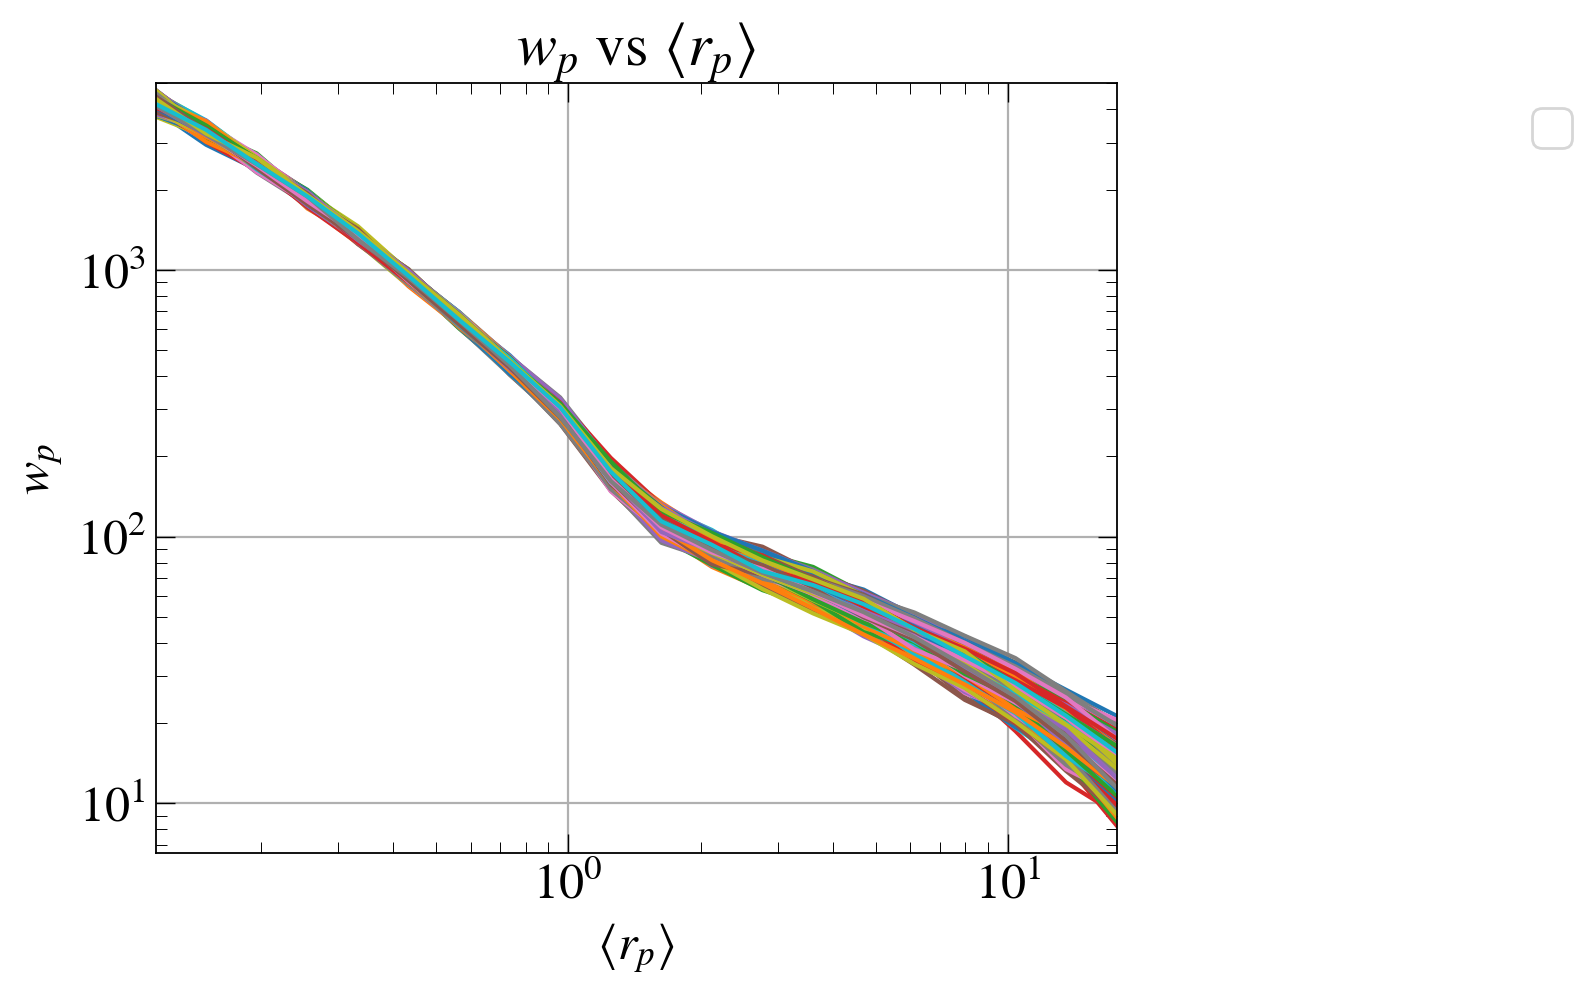

In [4]:
file = "wp_ph000.npz"
data = np.load(file)
all_wp = data['wp_']
all_rp = data['rp_avg']
for i in range (1, 25):
    file = f"wp_ph{i:03d}.npz"
    data = np.load(file)
    all_wp = np.concatenate((all_wp, data['wp_']))
    all_rp = np.concatenate((all_rp, data['rp_avg']))
rp_temp, wp_temp, stdev_temp = error_data(all_rp, all_wp)
print(np.max(all_wp))
plot_results(all_rp, all_wp, y_max= 5000, y_min = 6.5)

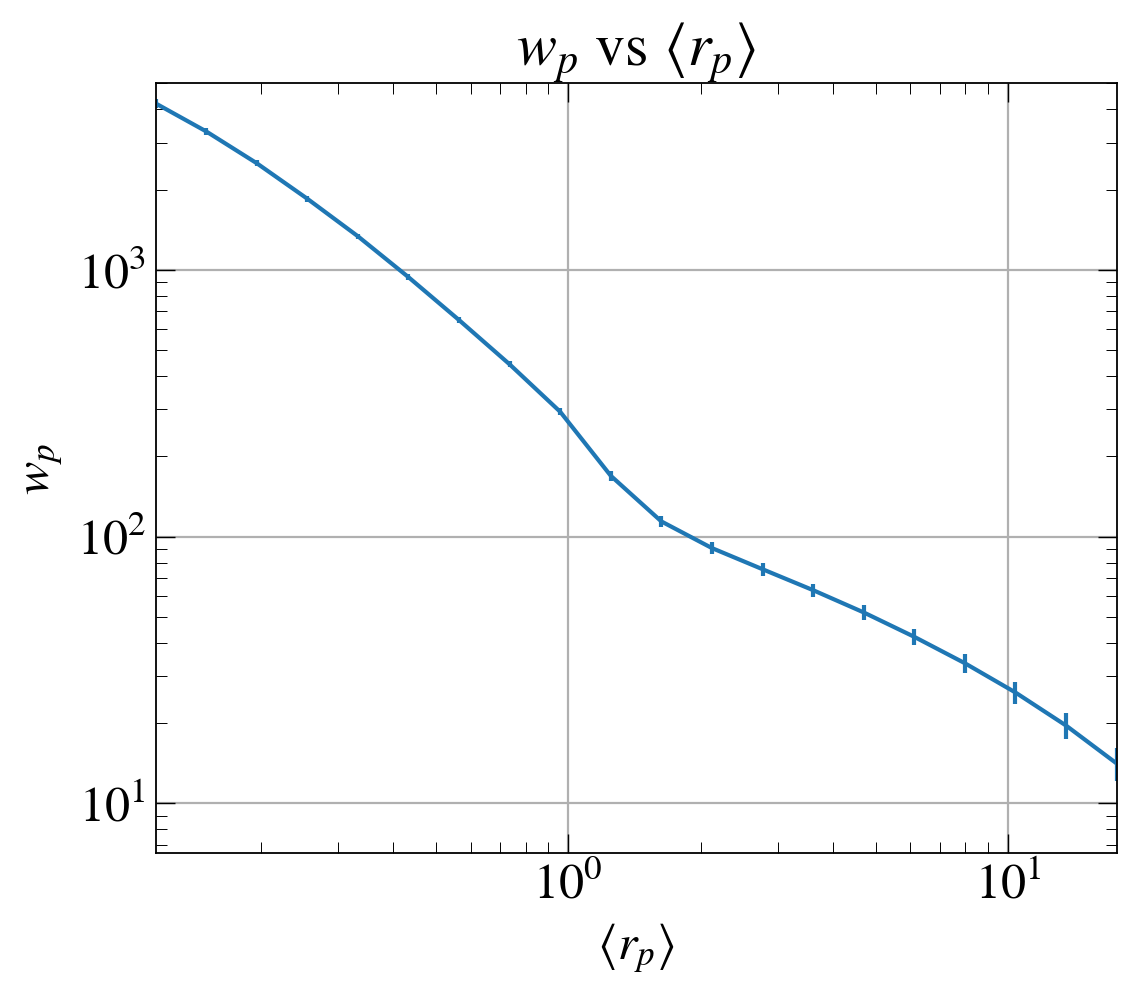

In [5]:
wp_vs_rpavg(all_rp, all_wp, y_max=5000, y_min = 6.5)
plt.show()

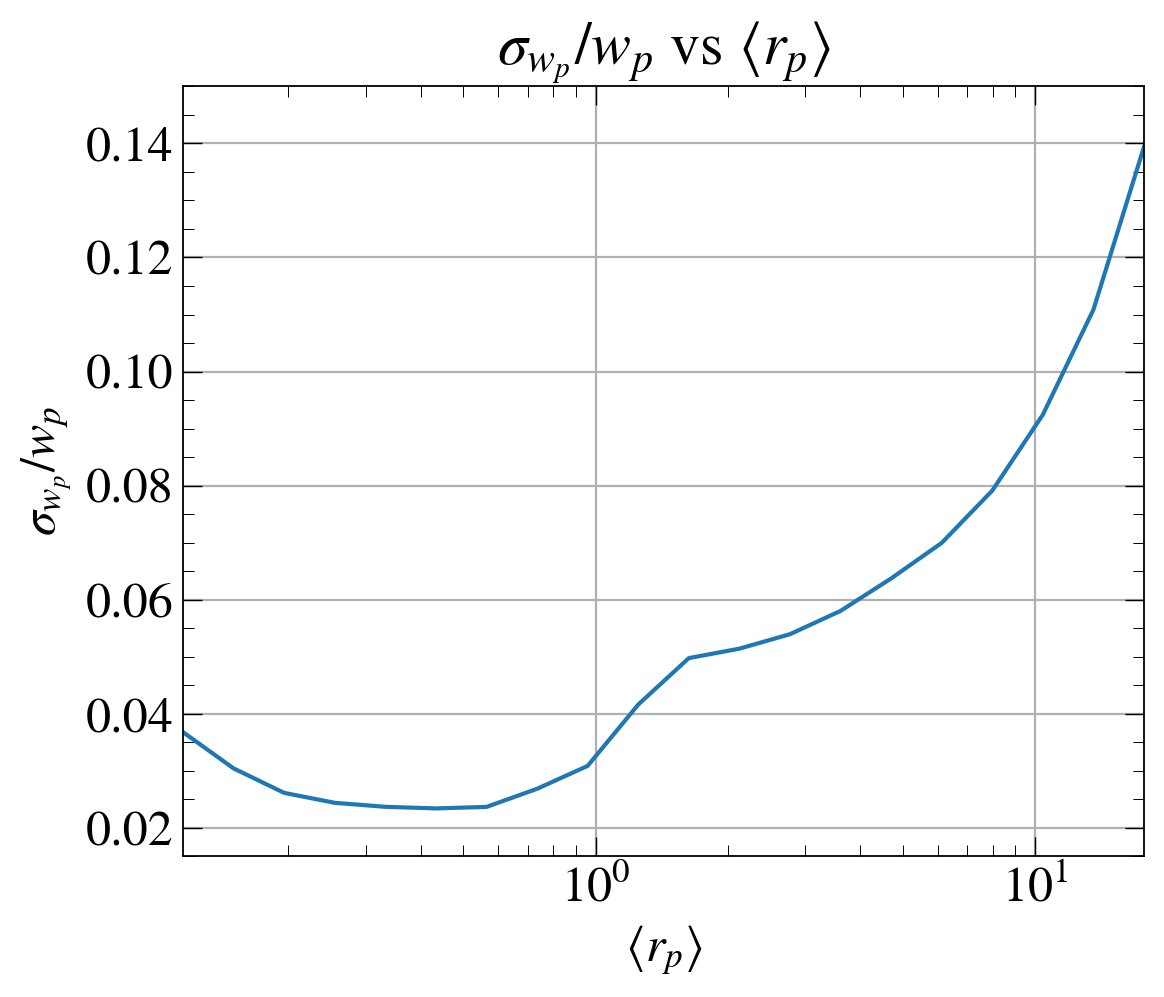

In [6]:
plot_fractional_error(all_rp, all_wp, y_max=0.15, y_min = 0.015)

# Plotting comparison: w/ vs w/o cross-volume comparison

In [7]:
data_no_cross = np.load("wp_subvol_no_cross.npz")
wp_no_cross = data_no_cross['wp_all']
rp_no_cross = data_no_cross['rp_all']

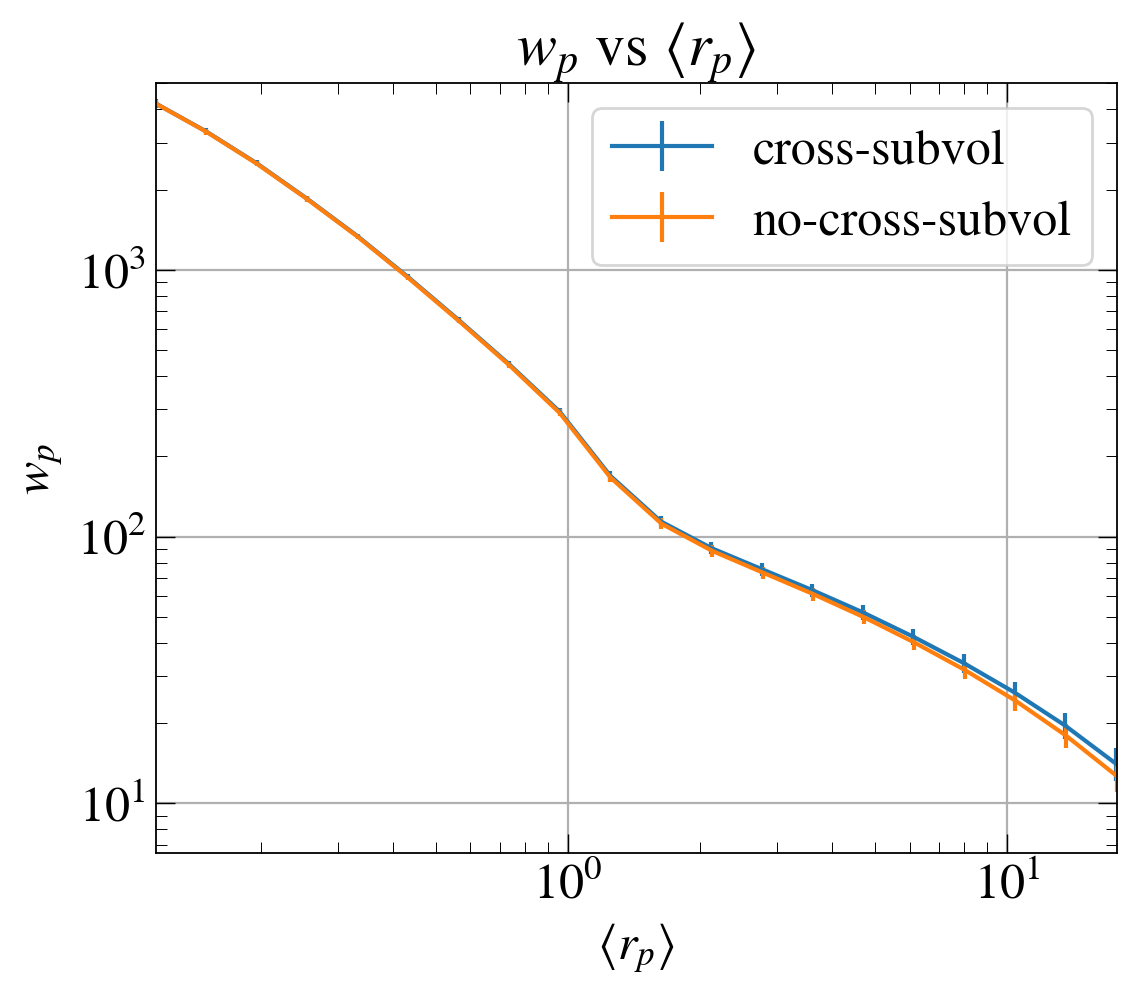

In [8]:
wp_vs_rpavg(all_rp, all_wp, y_max=5000, y_min = 6.5, legend = 'cross-subvol')
wp_vs_rpavg(rp_no_cross, wp_no_cross, y_max=5000, y_min = 6.5, legend = 'no-cross-subvol')
plt.legend()
plt.show()

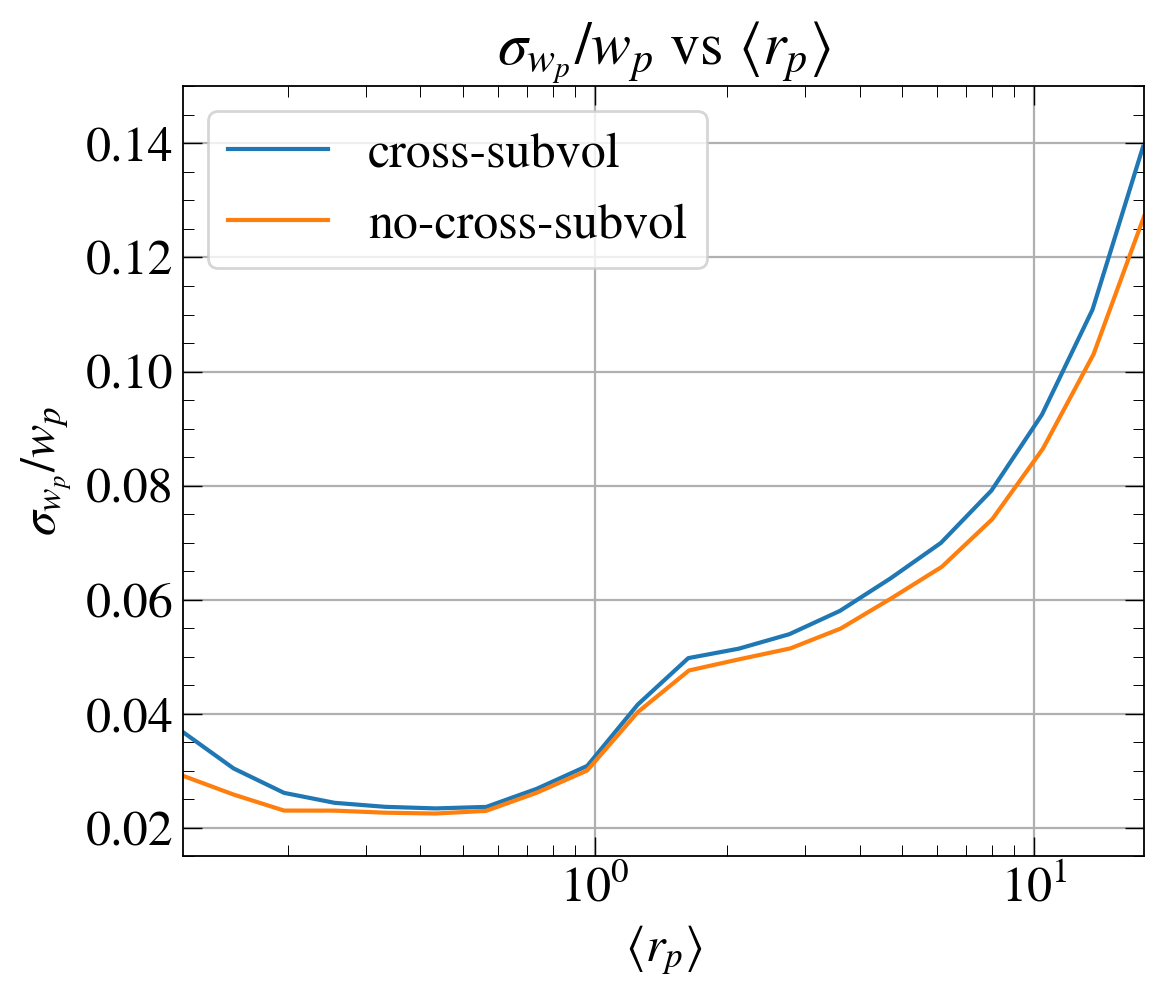

In [9]:
plot_fractional_error(all_rp, all_wp, y_max=0.15, y_min = 0.015)
plot_fractional_error(rp_no_cross, wp_no_cross, y_max=0.15, y_min = 0.015)
plt.legend(["cross-subvol", "no-cross-subvol"])

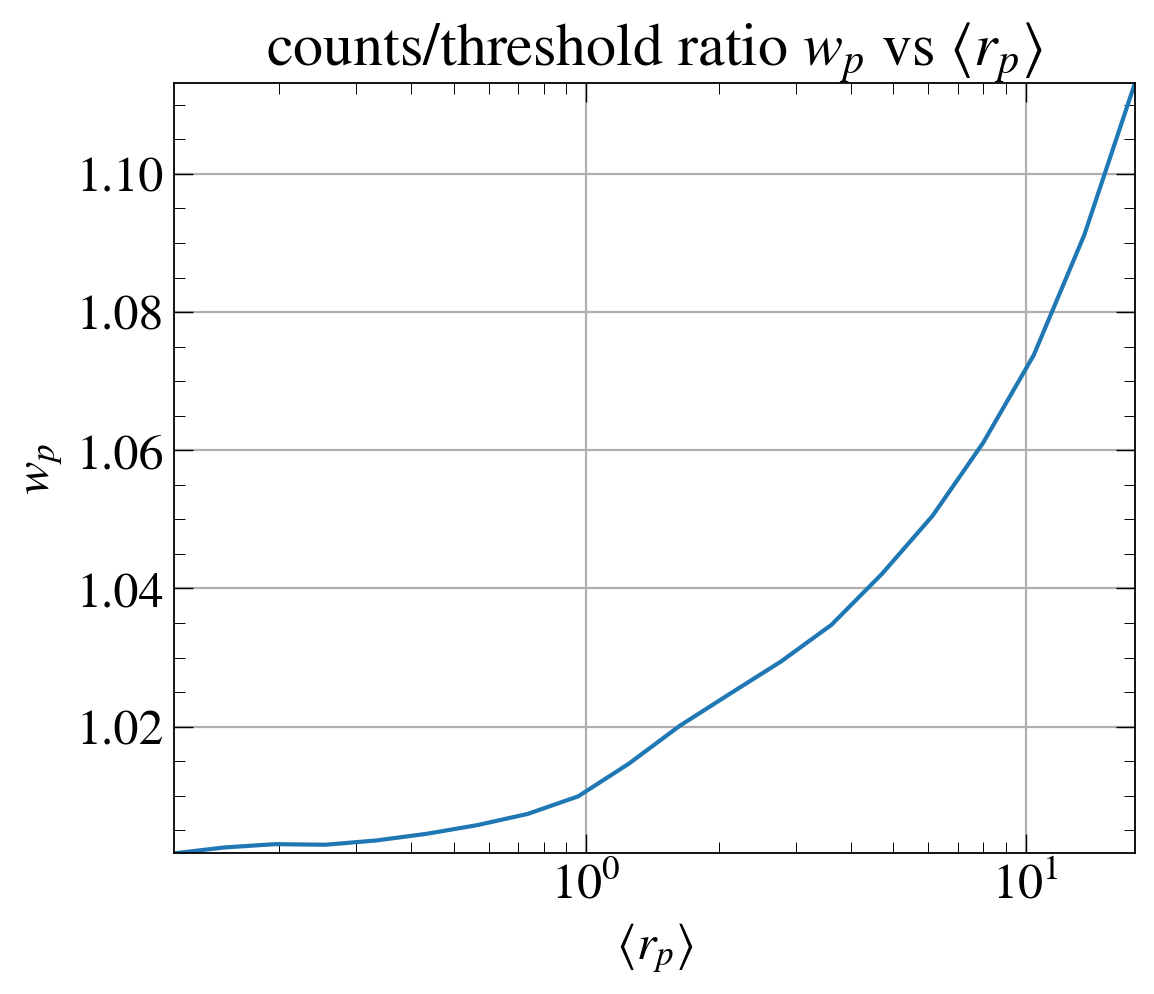

In [10]:
rpavg_ = all_rp
wp_ = all_wp
rpavg_mean_cross, wp_mean_cross, stdev_cross = error_data(rpavg_, wp_)
rpavg_mean_no_cross, wp_mean_no_cross, stdev_no_cross = error_data(rp_no_cross, wp_no_cross)
rp = (np.array(rpavg_mean_cross) + np.array(rpavg_mean_no_cross))/2
plt.plot(rp, np.array(wp_mean_cross)/np.array(wp_mean_no_cross))
plt.title(r'counts/threshold ratio $w_p$ vs $\langle r_p\rangle$')
plt.xlabel(r'$\langle r_p\rangle$')
plt.ylabel(r'$w_p$')
plt.xscale('log')